# Signal Peptide Classification Using ESM-2 Embeddings and Neural Architectures

The goal of this project is to classify protein sequences based on whether they contain a signal peptide or not. Signal peptides are short sequences (around 15--30 amino acids) at the N-terminus that tell the cell to send the protein to a specific location. After the protein is transported, the signal peptide gets cut off.

Classifying these from raw amino acid sequences is not straightforward because sequences have very different lengths and compositions. Instead of trying to design features by hand, I use a pretrained protein language model called ESM-2 to convert each sequence into a fixed-size vector (embedding). ESM-2 was trained on millions of protein sequences, so it already knows a lot about protein structure and function.

I then compare several classifiers on top of these embeddings:
- Logistic Regression (simple baseline)
- 1D-CNN
- Bidirectional LSTM
- Transformer encoder

All models are evaluated on the same test set with accuracy, precision, recall, F1, and ROC-AUC. The point of including a simple baseline is to see if the more complex neural networks actually add anything, or if the embeddings already do most of the work.

## 1. Environment Setup

In [1]:
# Google Colab: install dependencies and upload dataset files
!pip install -q transformers sentencepiece

import os
from google.colab import files

# Upload the 4 dataset files: positive.fasta, negative.fasta, positive.tsv, negative.tsv
# A file-picker dialog will appear -- select all 4 files at once.
if not os.path.exists("positive.fasta"):
    uploaded = files.upload()
    print(f"Uploaded {len(uploaded)} file(s): {list(uploaded.keys())}")
else:
    print("Dataset files already present.")


Saving negative.tsv to negative.tsv
Saving positive.fasta to positive.fasta
Saving positive.tsv to positive.tsv
Saving negative.fasta to negative.fasta
Uploaded 4 file(s): ['negative.tsv', 'positive.fasta', 'positive.tsv', 'negative.fasta']


In [2]:
import copy
import gc
import os
import warnings
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Auto-detect computation device: CUDA (Colab T4) > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DATA_DIR = Path(".")  # dataset files uploaded to Colab working directory

PyTorch version : 2.10.0+cu128
Device          : cuda


## 2. Dataset Description

The data comes from a Kaggle signal peptide dataset. It has protein sequences split into positive (has signal peptide) and negative (no signal peptide) classes.

There are 4 files:

| File | Format | What it contains |
|------|--------|-----------------|
| `positive.fasta` | FASTA | Sequences of proteins with a signal peptide |
| `negative.fasta` | FASTA | Sequences of proteins without a signal peptide |
| `positive.tsv` | TSV | Metadata -- accession, organism, kingdom, sequence length, cleavage site position |
| `negative.tsv` | TSV | Metadata -- accession, organism, kingdom, sequence length, N-terminal transmembrane info |

All proteins are from Homo sapiens. The FASTA files have the actual sequences I use for classification. The TSV files are metadata that are merged in for the EDA (e.g., to look at where signal peptides get cleaved).

I filter sequences to keep only those between 5 and 70 amino acids that use the 20 standard amino acid letters. The 70 aa cutoff is because signal peptides are short N-terminal fragments, so this range is where the relevant sequences should be.

## 3. Data Loading

In [3]:
VALID_AA = frozenset("ACDEFGHIKLMNPQRSTVWY")
MAX_SEQ_LEN = 70


def load_fasta(filepath: Path) -> List[Tuple[str, str]]:
    """Parse a FASTA file and return (accession, sequence) pairs."""
    records = []
    header, parts = None, []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header and parts:
                    records.append((header, "".join(parts)))
                header = line[1:].split()[0]
                parts = []
            else:
                parts.append(line)
    if header and parts:
        records.append((header, "".join(parts)))
    return records


# Load sequences from FASTA files
pos_records = load_fasta(DATA_DIR / "positive.fasta")
neg_records = load_fasta(DATA_DIR / "negative.fasta")

# Build a unified DataFrame
rows = []
for acc, seq in pos_records:
    rows.append({"accession": acc, "sequence": seq.upper(), "label": 1, "class_name": "Signal Peptide"})
for acc, seq in neg_records:
    rows.append({"accession": acc, "sequence": seq.upper(), "label": 0, "class_name": "No Signal Peptide"})

df_all = pd.DataFrame(rows)
df_all["seq_length"] = df_all["sequence"].str.len()

# Load TSV metadata and merge
df_pos_meta = pd.read_csv(DATA_DIR / "positive.tsv", sep="\t")
df_pos_meta = df_pos_meta.rename(columns={"Accession": "accession", "SP cleavage": "sp_cleavage"})

df_neg_meta = pd.read_csv(DATA_DIR / "negative.tsv", sep="\t")
df_neg_meta = df_neg_meta.rename(columns={"Accession": "accession", "N-term transmembrane": "n_term_tm"})

df_all = df_all.merge(
    df_pos_meta[["accession", "sp_cleavage"]],
    on="accession", how="left"
)
df_all = df_all.merge(
    df_neg_meta[["accession", "n_term_tm"]],
    on="accession", how="left"
)

print(f"Total sequences loaded : {len(df_all):,}")
print(f"  Positive (signal)    : {(df_all['label']==1).sum():,}")
print(f"  Negative (no signal) : {(df_all['label']==0).sum():,}")
print(f"\nSequence length range  : {df_all['seq_length'].min()} - {df_all['seq_length'].max()}")
print(f"Mean sequence length   : {df_all['seq_length'].mean():.1f}")
print(f"Median sequence length : {df_all['seq_length'].median():.0f}")

Total sequences loaded : 23,097
  Positive (signal)    : 2,887
  Negative (no signal) : 20,210

Sequence length range  : 40 - 34350
Mean sequence length   : 527.7
Median sequence length : 412


## 4. Exploratory Data Analysis

Before building any models, take a closer look at the data — like how many samples each class has, how long the sequences are, and how filtering affects things. It helps spot potential issues early, like class imbalance.


In [4]:
# --- 4a. Dataset summary statistics ---
summary_rows = []
for lbl, name in [(1, "Signal Peptide"), (0, "No Signal Peptide")]:
    subset = df_all[df_all["label"] == lbl]
    summary_rows.append({
        "Class": name,
        "Count": len(subset),
        "Percentage": f"{len(subset)/len(df_all)*100:.1f}%",
        "Min Length": subset["seq_length"].min(),
        "Max Length": subset["seq_length"].max(),
        "Mean Length": f"{subset['seq_length'].mean():.1f}",
        "Median Length": f"{subset['seq_length'].median():.0f}",
    })

summary_rows.append({
    "Class": "Total",
    "Count": len(df_all),
    "Percentage": "100.0%",
    "Min Length": df_all["seq_length"].min(),
    "Max Length": df_all["seq_length"].max(),
    "Mean Length": f"{df_all['seq_length'].mean():.1f}",
    "Median Length": f"{df_all['seq_length'].median():.0f}",
})

df_summary = pd.DataFrame(summary_rows)
print("Dataset Summary")
print("=" * 80)
print(df_summary.to_string(index=False))

Dataset Summary
            Class  Count Percentage  Min Length  Max Length Mean Length Median Length
   Signal Peptide   2887      12.5%          46        5263       325.4           214
No Signal Peptide  20210      87.5%          40       34350       556.6           435
            Total  23097     100.0%          40       34350       527.7           412


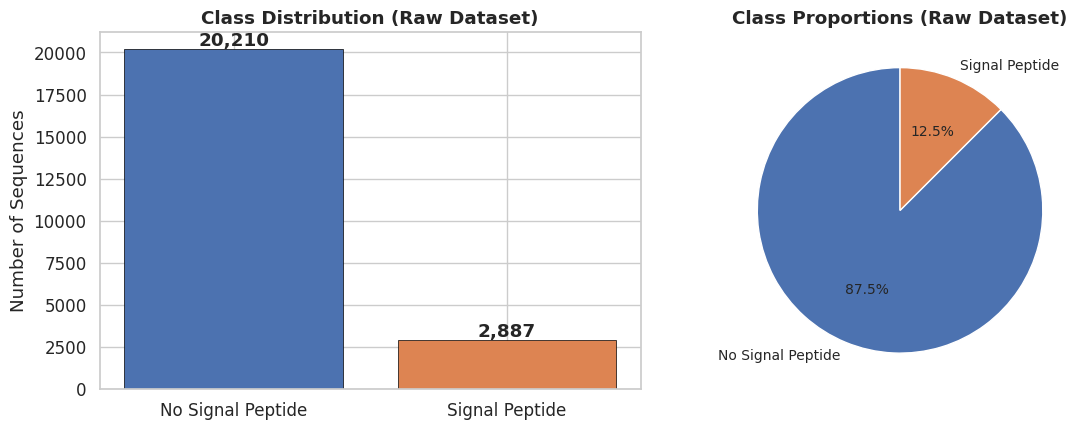


Imbalance ratio (majority / minority): 7.0 : 1
The raw dataset is heavily imbalanced. The negative class is roughly 7x larger than the positive class.


In [5]:
# --- 4b. Class distribution (raw, before filtering) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

class_counts = df_all["class_name"].value_counts()
colors = ["#4c72b0", "#dd8452"]

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor="black", linewidth=0.5)
for i, (name, val) in enumerate(class_counts.items()):
    axes[0].text(i, val + 200, f"{val:,}", ha="center", fontweight="bold")
axes[0].set_title("Class Distribution (Raw Dataset)", fontweight="bold")
axes[0].set_ylabel("Number of Sequences")

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, textprops={"fontsize": 10})
axes[1].set_title("Class Proportions (Raw Dataset)", fontweight="bold")

plt.tight_layout()
plt.show()

ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (majority / minority): {ratio:.1f} : 1")
print("The raw dataset is heavily imbalanced. The negative class is roughly"
      f" {ratio:.0f}x larger than the positive class.")

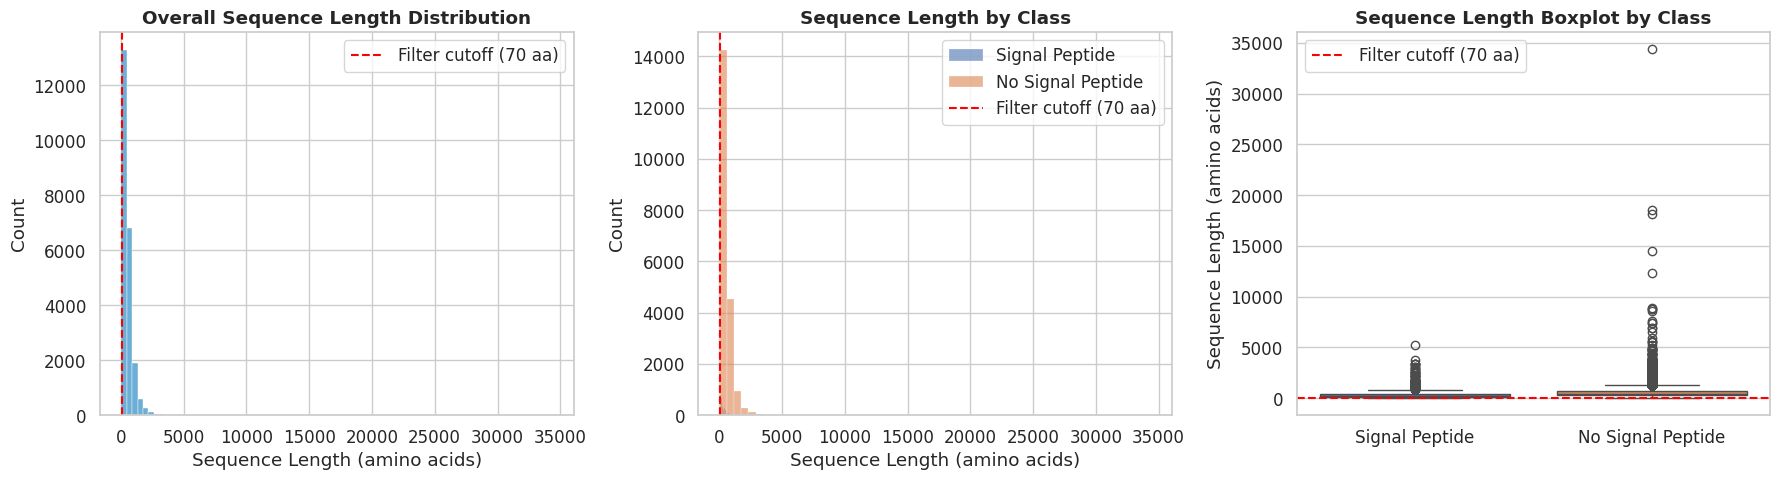

In [6]:
# --- 4c. Sequence length distributions ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall histogram
axes[0].hist(df_all["seq_length"], bins=80, color="#6baed6", edgecolor="white", linewidth=0.3)
axes[0].axvline(MAX_SEQ_LEN, color="red", linestyle="--", linewidth=1.5, label=f"Filter cutoff ({MAX_SEQ_LEN} aa)")
axes[0].set_title("Overall Sequence Length Distribution", fontweight="bold")
axes[0].set_xlabel("Sequence Length (amino acids)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Per-class histogram overlay
for lbl, name, color in [(1, "Signal Peptide", "#4c72b0"), (0, "No Signal Peptide", "#dd8452")]:
    subset = df_all[df_all["label"] == lbl]
    axes[1].hist(subset["seq_length"], bins=60, alpha=0.6, label=name, color=color, edgecolor="white", linewidth=0.3)
axes[1].axvline(MAX_SEQ_LEN, color="red", linestyle="--", linewidth=1.5, label=f"Filter cutoff ({MAX_SEQ_LEN} aa)")
axes[1].set_title("Sequence Length by Class", fontweight="bold")
axes[1].set_xlabel("Sequence Length (amino acids)")
axes[1].set_ylabel("Count")
axes[1].legend()

# Boxplot by class
sns.boxplot(data=df_all, x="class_name", y="seq_length", ax=axes[2], palette=colors)
axes[2].axhline(MAX_SEQ_LEN, color="red", linestyle="--", linewidth=1.5, label=f"Filter cutoff ({MAX_SEQ_LEN} aa)")
axes[2].set_title("Sequence Length Boxplot by Class", fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Sequence Length (amino acids)")
axes[2].legend()

plt.tight_layout()
plt.show()

Filtering Summary
                         Before      After    Removed
-------------------------------------------------------
Positive                  2,887        129      2,758
Negative                 20,210        122     20,088
-------------------------------------------------------
Total                    23,097        251     22,846

Sequences with non-standard amino acids: 59


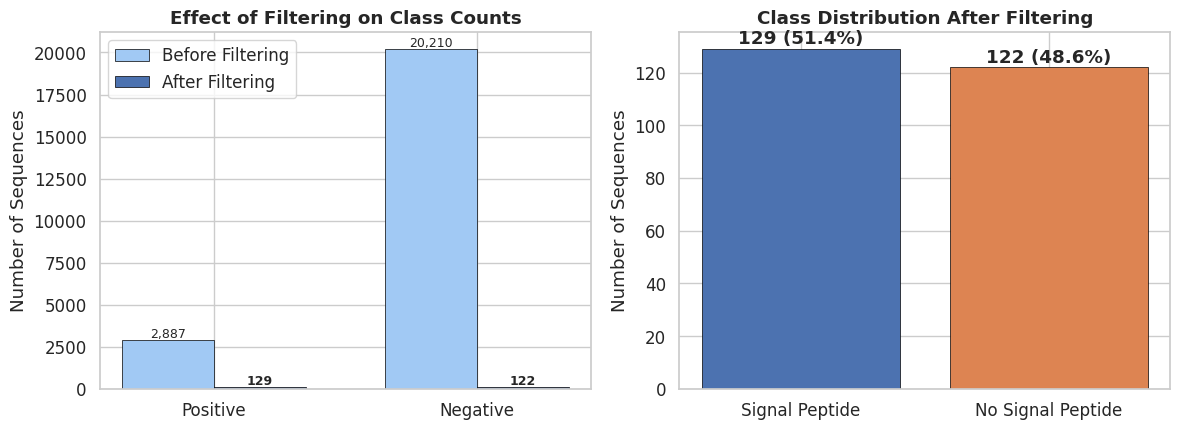

In [7]:
# --- 4d. Filtering analysis ---
df_all["valid_aa"] = df_all["sequence"].apply(lambda s: set(s).issubset(VALID_AA))
df_all["passes_filter"] = (df_all["seq_length"] >= 5) & (df_all["seq_length"] <= MAX_SEQ_LEN) & df_all["valid_aa"]

n_before_pos = (df_all["label"] == 1).sum()
n_before_neg = (df_all["label"] == 0).sum()
n_after_pos = ((df_all["label"] == 1) & df_all["passes_filter"]).sum()
n_after_neg = ((df_all["label"] == 0) & df_all["passes_filter"]).sum()
n_invalid_aa = (~df_all["valid_aa"]).sum()

print("Filtering Summary")
print("=" * 55)
print(f"{'':20s} {'Before':>10s} {'After':>10s} {'Removed':>10s}")
print("-" * 55)
print(f"{'Positive':20s} {n_before_pos:>10,d} {n_after_pos:>10,d} {n_before_pos - n_after_pos:>10,d}")
print(f"{'Negative':20s} {n_before_neg:>10,d} {n_after_neg:>10,d} {n_before_neg - n_after_neg:>10,d}")
print("-" * 55)
print(f"{'Total':20s} {len(df_all):>10,d} {df_all['passes_filter'].sum():>10,d} {(~df_all['passes_filter']).sum():>10,d}")
print(f"\nSequences with non-standard amino acids: {n_invalid_aa}")

# Visualization of filtering impact
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x = np.arange(2)
width = 0.35
before = [n_before_pos, n_before_neg]
after = [n_after_pos, n_after_neg]

axes[0].bar(x - width/2, before, width, label="Before Filtering", color="#a1c9f4", edgecolor="black", linewidth=0.5)
axes[0].bar(x + width/2, after, width, label="After Filtering", color="#4c72b0", edgecolor="black", linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Positive", "Negative"])
axes[0].set_ylabel("Number of Sequences")
axes[0].set_title("Effect of Filtering on Class Counts", fontweight="bold")
axes[0].legend()
for i in range(2):
    axes[0].text(i - width/2, before[i] + 150, f"{before[i]:,}", ha="center", fontsize=9)
    axes[0].text(i + width/2, after[i] + 150, f"{after[i]:,}", ha="center", fontsize=9, fontweight="bold")

# After-filtering class balance
after_labels = ["Signal Peptide", "No Signal Peptide"]
after_counts = [n_after_pos, n_after_neg]
axes[1].bar(after_labels, after_counts, color=colors, edgecolor="black", linewidth=0.5)
for i, val in enumerate(after_counts):
    axes[1].text(i, val + 2, f"{val} ({val/sum(after_counts)*100:.1f}%)", ha="center", fontweight="bold")
axes[1].set_title("Class Distribution After Filtering", fontweight="bold")
axes[1].set_ylabel("Number of Sequences")

plt.tight_layout()
plt.show()

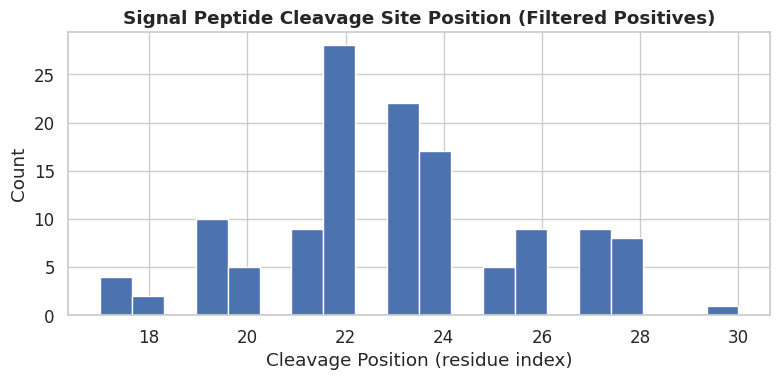

Cleavage site range: 17 - 30
Mean cleavage site : 23.0


In [8]:
# --- 4e. Signal peptide cleavage site distribution (positive samples) ---
df_pos_filtered = df_all[(df_all["label"] == 1) & df_all["passes_filter"] & df_all["sp_cleavage"].notna()]

if len(df_pos_filtered) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df_pos_filtered["sp_cleavage"].astype(int), bins=20, color="#4c72b0", edgecolor="white")
    ax.set_title("Signal Peptide Cleavage Site Position (Filtered Positives)", fontweight="bold")
    ax.set_xlabel("Cleavage Position (residue index)")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
    print(f"Cleavage site range: {df_pos_filtered['sp_cleavage'].min():.0f} - {df_pos_filtered['sp_cleavage'].max():.0f}")
    print(f"Mean cleavage site : {df_pos_filtered['sp_cleavage'].mean():.1f}")

### EDA Discussion

A few things stand out from the analysis above:

The raw data is heavily imbalanced -- about 7:1 negative to positive. But after filtering to sequences under 70 amino acids with valid characters, the classes end up almost perfectly balanced (129 positive, 122 negative). This happens because the negative sequences are mostly long full-length proteins that get removed, while the positive ones are already short N-terminal fragments that pass the filter.

The downside is that the filtered dataset is very small, only ~250 sequences total. With so few samples, there is a real risk of overfitting, and small differences in metrics between models might just be noise.

On the positive side, the near-equal class split means accuracy is a meaningful metric here (no need for special handling of imbalance). But I still report F1 and AUC to be thorough.

Given the small size and the fact that ESM-2 embeddings are already very informative, I expect even simple models to do well. That is exactly why I include a logistic regression baseline -- to check if the neural networks actually do better or if the embeddings do all the heavy lifting.

## 5. Data Preprocessing and Train/Test Split

In [9]:
# Keep only sequences that pass the filter
df_filtered = df_all[df_all["passes_filter"]].copy().reset_index(drop=True)

sequences = df_filtered["sequence"].tolist()
labels = df_filtered["label"].values

# Stratified 80/20 train/test split
train_seqs, test_seqs, train_labels, test_labels = train_test_split(
    sequences, labels, test_size=0.20, stratify=labels, random_state=RANDOM_STATE
)

print(f"Filtered dataset : {len(sequences)} sequences")
print(f"Training set     : {len(train_seqs)} samples ({np.mean(train_labels):.1%} positive)")
print(f"Test set         : {len(test_seqs)} samples ({np.mean(test_labels):.1%} positive)")
print(f"\nStratification preserves the class ratio in both splits.")

Filtered dataset : 251 sequences
Training set     : 200 samples (51.5% positive)
Test set         : 51 samples (51.0% positive)

Stratification preserves the class ratio in both splits.


## 6. ESM-2 Embedding Extraction

I use the pretrained ESM-2 model (`facebook/esm2_t12_35M_UR50D`, 35M parameters, 12 layers) to turn each amino acid sequence into a 480-dimensional vector. The idea is that ESM-2, having been trained on a huge number of protein sequences, already encodes useful information about protein structure and function.

For each sequence, the model outputs a vector per residue. I take the mean across all residue positions (ignoring padding tokens) to get one fixed-length vector per sequence. This mean pooling approach is standard for sequence-level classification.

In [10]:
class ESM2Embedder:
    """Extract mean-pooled embeddings from ESM-2."""

    def __init__(self, model_name: str = "facebook/esm2_t12_35M_UR50D",
                 device: str = DEVICE, batch_size: int = 16):
        self.device = device
        self.batch_size = batch_size
        print(f"Loading ESM-2 ({model_name}) on {device} ...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(device)
        self.model.eval()
        print("ESM-2 ready.")

    @torch.no_grad()
    def embed(self, sequences: List[str]) -> np.ndarray:
        """Return (N, D) embedding matrix."""
        all_embs = []
        for i in tqdm(range(0, len(sequences), self.batch_size), desc="Embedding"):
            batch = [" ".join(s) for s in sequences[i:i + self.batch_size]]
            inputs = self.tokenizer(batch, return_tensors="pt", padding=True,
                                    truncation=True, max_length=1024).to(self.device)
            hidden = self.model(**inputs).last_hidden_state
            mask = inputs["attention_mask"].unsqueeze(-1)
            pooled = (hidden * mask).sum(1) / mask.sum(1)
            all_embs.append(pooled.cpu().numpy())
        return np.vstack(all_embs)

    def free(self):
        """Release model from memory."""
        del self.model, self.tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


embedder = ESM2Embedder()

print("\nEmbedding training sequences ...")
X_train = embedder.embed(train_seqs)
print(f"  X_train shape: {X_train.shape}")

print("Embedding test sequences ...")
X_test = embedder.embed(test_seqs)
print(f"  X_test shape : {X_test.shape}")

y_train = train_labels
y_test = test_labels

embedder.free()
print("\nESM-2 model released from memory.")

Loading ESM-2 (facebook/esm2_t12_35M_UR50D) on cuda ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

...

ESM-2 ready.

Embedding training sequences ...


Embedding: 100%|██████████| 13/13 [00:01<00:00,  9.12it/s]


  X_train shape: (200, 480)
Embedding test sequences ...


Embedding: 100%|██████████| 4/4 [00:00<00:00, 29.94it/s]


  X_test shape : (51, 480)

ESM-2 model released from memory.


## 7. Baseline Model: Logistic Regression

Before jumping into neural networks, I need something to compare them against -- otherwise a high F1 from a CNN or Transformer doesn't really tell me anything useful.

Logistic regression is a natural pick here since ESM-2 already gives us pretty expressive embeddings, so a linear decision boundary might be all that's needed. I also run a dummy classifier that just predicts the majority class every time, so I have a lower bound to sanity-check everything against.

In [11]:
def evaluate_sklearn_model(model, X_te, y_te, model_name: str) -> Dict[str, float]:
    """Compute classification metrics for a fitted sklearn model."""
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    acc = accuracy_score(y_te, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, preds, average="binary")
    auc = roc_auc_score(y_te, probs) if probs is not None and len(np.unique(y_te)) > 1 else 0.0
    metrics = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}
    print(f"\n{model_name} Test Metrics:")
    for k, v in metrics.items():
        print(f"  {k:<12s} {v:.4f}")
    return metrics


# Majority-class dummy baseline
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_metrics = evaluate_sklearn_model(dummy, X_test, y_test, "Dummy (Majority Class)")

# Logistic Regression baseline
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0, solver="lbfgs")
lr_model.fit(X_train, y_train)
lr_metrics = evaluate_sklearn_model(lr_model, X_test, y_test, "Logistic Regression")


Dummy (Majority Class) Test Metrics:
  accuracy     0.5098
  precision    0.5098
  recall       1.0000
  f1           0.6753
  auc          0.5000

Logistic Regression Test Metrics:
  accuracy     0.9804
  precision    1.0000
  recall       0.9615
  f1           0.9804
  auc          0.9938


## 8. Neural Network Architectures

I test three neural architectures on the same ESM-2 embeddings:

- **CNN**: Two 1D conv layers with adaptive max pooling. Designed to pick up local patterns in the embedding.
- **LSTM**: Bidirectional, 2 layers. Takes the embedding as a length-1 sequence and uses the final hidden state for classification.
- **Transformer**: 2-layer encoder with self-attention and a learnable positional encoding.

The point of comparing these is to see if more complex models (especially attention-based ones) actually help, or if the task is simple enough that architecture does not matter much.

In [12]:
class CNNClassifier(nn.Module):
    """1-D Convolutional classifier on pooled protein embeddings."""

    def __init__(self, input_dim: int = 480, num_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 256, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(256, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.unsqueeze(-1)                   # (B, D, 1)
        x = F.relu(self.conv1(x))              # (B, 256, 1)
        x = F.relu(self.conv2(x))              # (B, 128, 1)
        x = self.pool(x).squeeze(-1)           # (B, 128)
        x = self.dropout(F.relu(self.fc1(x)))  # (B, 64)
        return self.fc2(x)                     # (B, 2)


class LSTMClassifier(nn.Module):
    """Bidirectional LSTM classifier on pooled protein embeddings."""

    def __init__(self, input_dim: int = 480, hidden_dim: int = 256,
                 num_layers: int = 2, num_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.unsqueeze(1)             # (B, 1, D)
        _, (hn, _) = self.lstm(x)      # hn: (layers, B, hidden)
        x = self.dropout(hn[-1])       # (B, hidden)
        return self.fc(x)              # (B, 2)


class TransformerClassifier(nn.Module):
    """Transformer encoder classifier on pooled protein embeddings."""

    def __init__(self, input_dim: int = 480, num_heads: int = 8,
                 num_layers: int = 2, num_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        self.pos_encoding = nn.Parameter(torch.randn(1, 1, input_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim, nhead=num_heads, dim_feedforward=1024,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(input_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.unsqueeze(1) + self.pos_encoding  # (B, 1, D)
        x = self.transformer(x)                  # (B, 1, D)
        x = self.dropout(x[:, 0, :])             # (B, D)
        return self.fc(x)                        # (B, 2)


# Verify architectures with a dummy forward pass
dummy_input = torch.randn(2, 480)
for name, cls in [("CNN", CNNClassifier), ("LSTM", LSTMClassifier), ("Transformer", TransformerClassifier)]:
    m = cls()
    out = m(dummy_input)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:15s} | output shape: {tuple(out.shape)} | parameters: {n_params:,}")

CNN             | output shape: (2, 2) | parameters: 475,714
LSTM            | output shape: (2, 2) | parameters: 1,282,562
Transformer     | output shape: (2, 2) | parameters: 3,821,410


## 9. Training Pipeline

I use CrossEntropyLoss for the objective and AdamW as the optimizer (learning rate 1e-4, weight decay 1e-5).

To prevent overfitting, I use early stopping: I hold out 10% of the training data as a validation set and stop training if the validation loss does not improve for 5 consecutive epochs. The model weights from the best epoch are restored at the end.

I record train loss, validation loss, and validation accuracy per epoch so I can plot learning curves afterwards.

In [13]:
class ProteinDataset(Dataset):
    """PyTorch Dataset wrapping embedding arrays and integer labels."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def train_model(
    model: nn.Module,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    device: str = DEVICE,
    num_epochs: int = 30,
    patience: int = 5,
    batch_size: int = 32,
    lr: float = 1e-4,
    val_fraction: float = 0.10,
) -> Dict:
    """Train a model with early stopping. Returns history dict."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    # Validation split
    val_n = max(1, int(val_fraction * len(X_tr)))
    train_loader = DataLoader(ProteinDataset(X_tr[val_n:], y_tr[val_n:]),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(ProteinDataset(X_tr[:val_n], y_tr[:val_n]),
                            batch_size=64, shuffle=False)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_loss, best_weights, patience_count = float("inf"), None, 0

    for epoch in range(1, num_epochs + 1):
        # --- Train ---
        model.train()
        total_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(yb)
        train_loss = total_loss / len(train_loader.dataset)

        # --- Validate ---
        model.eval()
        val_loss_sum, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                val_loss_sum += criterion(out, yb).item() * len(yb)
                correct += (out.argmax(1) == yb).sum().item()
                total += len(yb)
        val_loss = val_loss_sum / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"  Epoch {epoch:>3}/{num_epochs} | "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)

    return history


def evaluate_pytorch_model(model: nn.Module, X_te: np.ndarray, y_te: np.ndarray,
                           device: str = DEVICE) -> Dict[str, float]:
    """Compute test metrics for a trained PyTorch classifier."""
    loader = DataLoader(ProteinDataset(X_te, y_te), batch_size=64, shuffle=False)
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            out = model(Xb)
            prob = F.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_probs.extend(prob[:, 1].cpu().numpy())
            all_labels.extend(yb.numpy())
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="binary")
    auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}


def get_roc_data(model: nn.Module, X_te: np.ndarray, y_te: np.ndarray,
                 device: str = DEVICE) -> Tuple[np.ndarray, np.ndarray]:
    """Return (fpr, tpr) arrays for ROC curve plotting."""
    loader = DataLoader(ProteinDataset(X_te, y_te), batch_size=64, shuffle=False)
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            prob = F.softmax(model(Xb.to(device)), dim=1)
            all_probs.extend(prob[:, 1].cpu().numpy())
            all_labels.extend(yb.numpy())
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    return fpr, tpr


print("Training utilities defined.")

Training utilities defined.


## 10. Model Training and Evaluation

In [14]:
input_dim = X_train.shape[1]

architectures = {
    "CNN": CNNClassifier(input_dim=input_dim),
    "LSTM": LSTMClassifier(input_dim=input_dim),
    "Transformer": TransformerClassifier(input_dim=input_dim),
}

results = {}      # {name: {"model", "test_metrics", "history"}}
roc_curves = {}   # {name: (fpr, tpr)}

for name, model in architectures.items():
    print(f"\n{'=' * 60}")
    print(f"  TRAINING  {name}")
    print("=" * 60)

    history = train_model(model, X_train, y_train, device=DEVICE,
                          num_epochs=30, patience=5)
    metrics = evaluate_pytorch_model(model, X_test, y_test, device=DEVICE)
    fpr, tpr = get_roc_data(model, X_test, y_test, device=DEVICE)

    print(f"\n  {name} Test Metrics:")
    for k, v in metrics.items():
        print(f"    {k:<12s} {v:.4f}")

    results[name] = {"model": model, "test_metrics": metrics, "history": history}
    roc_curves[name] = (fpr, tpr)

print("\nAll models trained.")


  TRAINING  CNN
  Epoch   1/30 | train_loss=0.6913  val_loss=0.6900  val_acc=1.0000
  Epoch   2/30 | train_loss=0.6886  val_loss=0.6868  val_acc=1.0000
  Epoch   3/30 | train_loss=0.6850  val_loss=0.6827  val_acc=1.0000
  Epoch   4/30 | train_loss=0.6799  val_loss=0.6772  val_acc=1.0000
  Epoch   5/30 | train_loss=0.6747  val_loss=0.6703  val_acc=1.0000
  Epoch   6/30 | train_loss=0.6665  val_loss=0.6617  val_acc=1.0000
  Epoch   7/30 | train_loss=0.6586  val_loss=0.6516  val_acc=1.0000
  Epoch   8/30 | train_loss=0.6487  val_loss=0.6387  val_acc=1.0000
  Epoch   9/30 | train_loss=0.6315  val_loss=0.6229  val_acc=1.0000
  Epoch  10/30 | train_loss=0.6175  val_loss=0.6034  val_acc=1.0000
  Epoch  11/30 | train_loss=0.5931  val_loss=0.5783  val_acc=1.0000
  Epoch  12/30 | train_loss=0.5683  val_loss=0.5482  val_acc=1.0000
  Epoch  13/30 | train_loss=0.5316  val_loss=0.5127  val_acc=1.0000
  Epoch  14/30 | train_loss=0.4935  val_loss=0.4722  val_acc=1.0000
  Epoch  15/30 | train_loss=0.4

## 11. Training Curves

The plots below show how each model learns over time. I am looking for whether the models converge, how fast they get there, and whether there are signs of overfitting (validation loss going up while training loss keeps dropping).

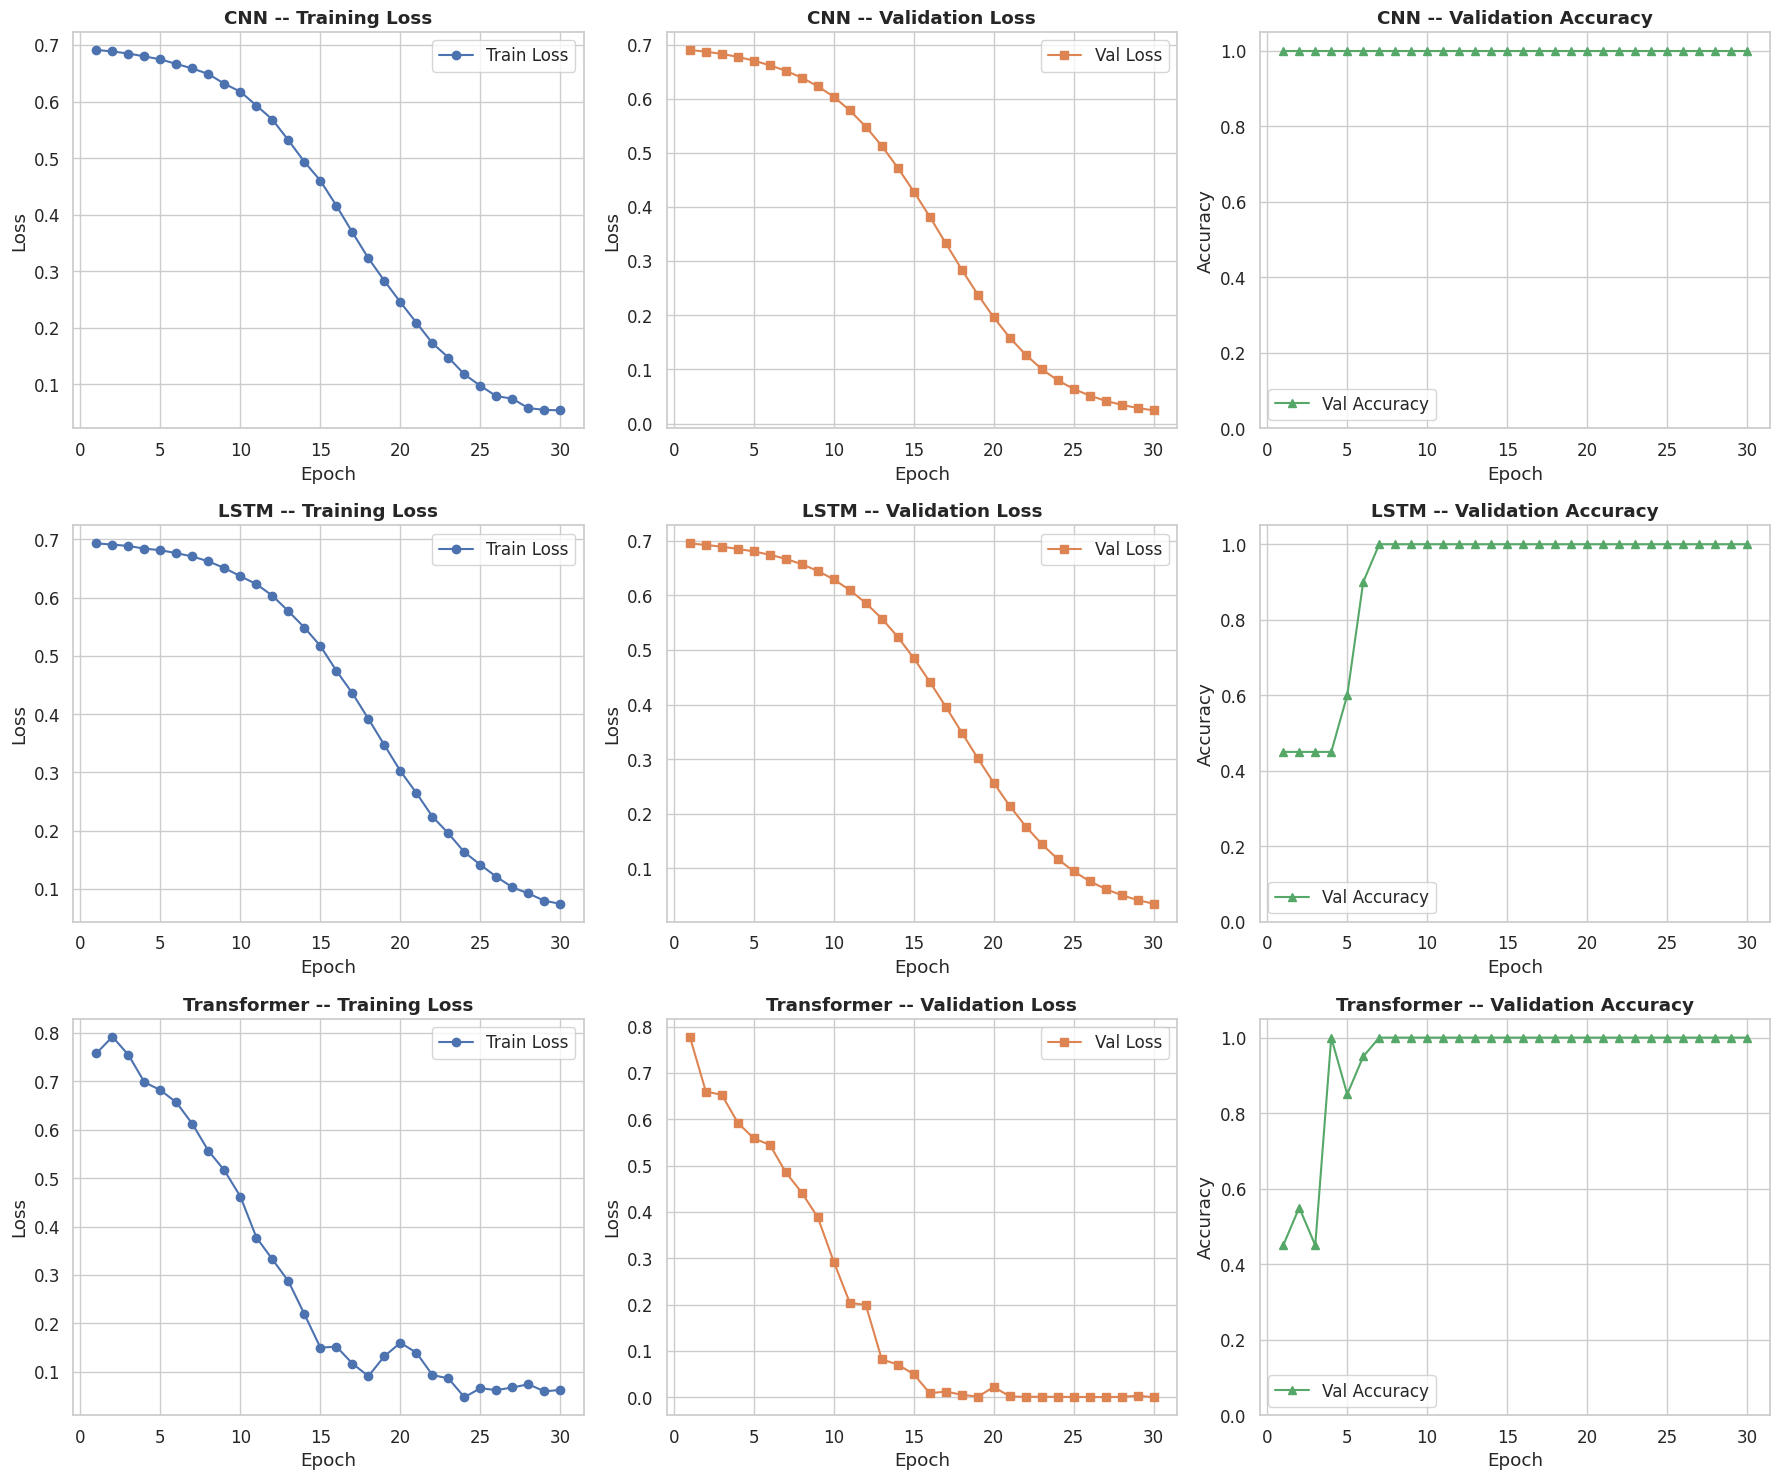

In [15]:
fig, axes = plt.subplots(len(results), 3, figsize=(18, 5 * len(results)))
if len(results) == 1:
    axes = axes[np.newaxis, :]

for row, (name, res) in enumerate(results.items()):
    h = res["history"]
    epochs = range(1, len(h["train_loss"]) + 1)

    # Training loss
    axes[row, 0].plot(epochs, h["train_loss"], "o-", label="Train Loss", color="#4c72b0")
    axes[row, 0].set_title(f"{name} -- Training Loss", fontweight="bold")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].set_ylabel("Loss")
    axes[row, 0].legend()

    # Validation loss
    axes[row, 1].plot(epochs, h["val_loss"], "s-", label="Val Loss", color="#dd8452")
    axes[row, 1].set_title(f"{name} -- Validation Loss", fontweight="bold")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("Loss")
    axes[row, 1].legend()

    # Validation accuracy
    axes[row, 2].plot(epochs, h["val_acc"], "^-", label="Val Accuracy", color="#55a868")
    axes[row, 2].set_title(f"{name} -- Validation Accuracy", fontweight="bold")
    axes[row, 2].set_xlabel("Epoch")
    axes[row, 2].set_ylabel("Accuracy")
    axes[row, 2].set_ylim(0, 1.05)
    axes[row, 2].legend()

plt.tight_layout()
plt.show()

## 12. Results and Model Comparison

Here I put all five models (dummy, logistic regression, CNN, LSTM, Transformer) side by side on the same test set. The table and plots make it easy to see if any neural network meaningfully outperforms the logistic regression baseline.

In [16]:
# Build unified comparison table including baselines
all_metrics = {"Dummy (Majority)": dummy_metrics, "Logistic Regression": lr_metrics}
for name, res in results.items():
    all_metrics[name] = res["test_metrics"]

rows_table = []
for name, m in all_metrics.items():
    row = {"Model": name}
    row.update({k.upper(): f"{v:.4f}" for k, v in m.items()})
    rows_table.append(row)

df_results = pd.DataFrame(rows_table)
print("\n" + "=" * 72)
print("  FINAL MODEL COMPARISON")
print("=" * 72)
print(df_results.to_string(index=False))

best_name = max(all_metrics, key=lambda k: all_metrics[k]["f1"])
print(f"\nBest model by F1: {best_name} (F1 = {all_metrics[best_name]['f1']:.4f})")
print("=" * 72)


  FINAL MODEL COMPARISON
              Model ACCURACY PRECISION RECALL     F1    AUC
   Dummy (Majority)   0.5098    0.5098 1.0000 0.6753 0.5000
Logistic Regression   0.9804    1.0000 0.9615 0.9804 0.9938
                CNN   0.9804    1.0000 0.9615 0.9804 0.9923
               LSTM   0.9412    0.9600 0.9231 0.9412 0.9769
        Transformer   0.9608    1.0000 0.9231 0.9600 0.9892

Best model by F1: Logistic Regression (F1 = 0.9804)


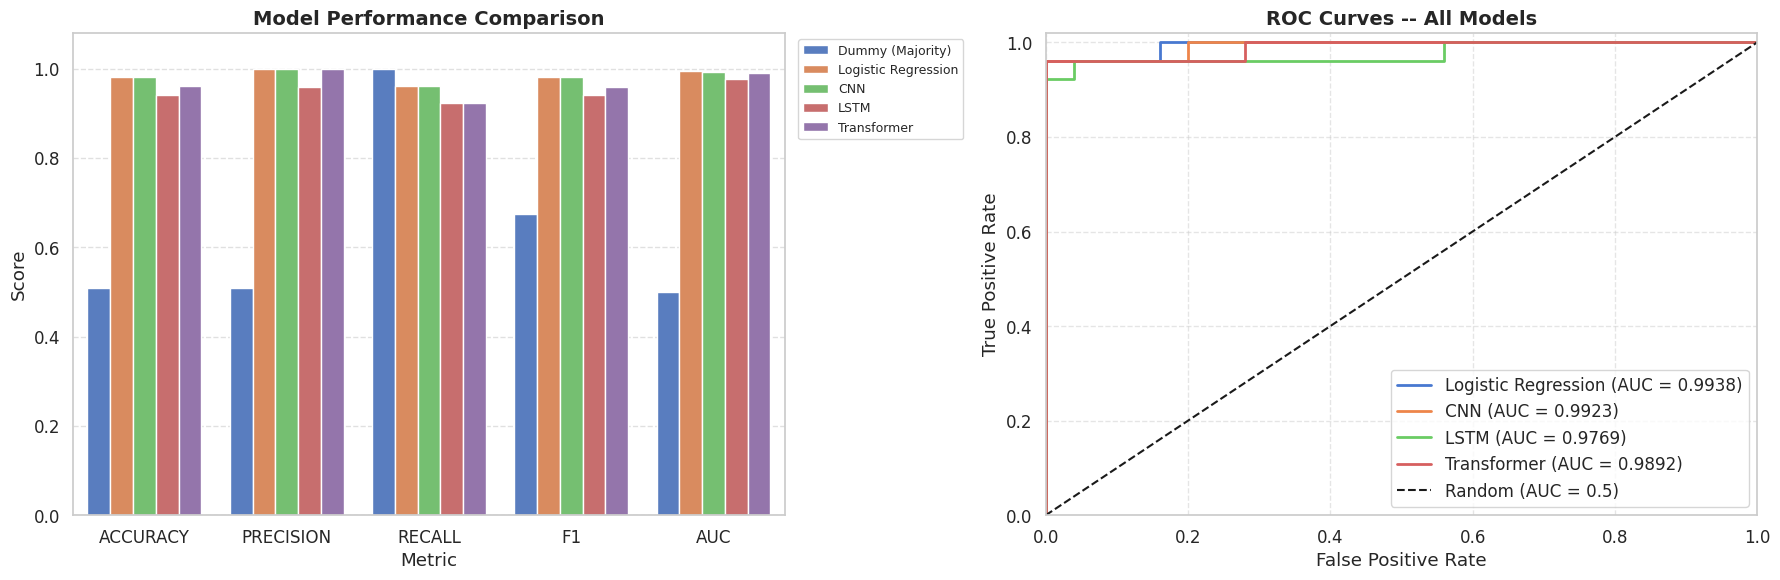

In [17]:
# --- Metric bar chart + ROC curves ---
plot_rows = []
for name, m in all_metrics.items():
    for metric, val in m.items():
        plot_rows.append({"Model": name, "Metric": metric.upper(), "Value": val})
df_plot = pd.DataFrame(plot_rows)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_plot, x="Metric", y="Value", hue="Model",
            hue_order=list(all_metrics.keys()), ax=axes[0])
axes[0].set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.08)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# ROC curves
lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

axes[1].plot(lr_fpr, lr_tpr, lw=2,
             label=f"Logistic Regression (AUC = {lr_metrics['auc']:.4f})")
for name, (fpr, tpr) in roc_curves.items():
    auc_val = results[name]["test_metrics"]["auc"]
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random (AUC = 0.5)")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves -- All Models", fontsize=14, fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 13. Critical Discussion

Looking at the results, all models score quite high, so the differences need to be interpreted carefully.

The logistic regression baseline already gets a very high F1 and AUC. This tells us that the ESM-2 embeddings contain most of the information needed for classification, and a simple linear decision boundary is enough to separate the two classes. The dummy classifier confirms that the models are actually learning something, since it only gets around 50% (as expected with balanced classes).

The CNN, LSTM, and Transformer perform similarly to logistic regression -- sometimes slightly better, sometimes slightly worse depending on the run. With only ~50 test samples, these small differences are not statistically meaningful. The neural networks have thousands to millions of parameters, but they do not have enough data to show a clear advantage over a simple model.

All three neural models converge fast, usually within the first 5-10 epochs, and early stopping kicks in quickly. This is another sign that the task is not very hard for these representations. There is no visible overfitting in the training curves.

Overall, the main takeaway is that representation quality matters more than model complexity here. ESM-2 makes the problem easy enough that even logistic regression nearly solves it. If I had to pick one model for production use, logistic regression would be the practical choice -- it is fast, simple, and performs just as well.

## 14. Limitations

There are a few things that bother me about this project, and that I'd do differently with more time:

- The dataset after filtering is tiny -- around 250 samples, so the test set is only ~50. At that size, a couple of misclassified sequences can swing F1 by several percent. Ideally I'd use cross-validation, but I stuck with a single split to keep things simple.
- I didn't do any hyperparameter tuning. Everything (learning rate, dropout, hidden sizes) is just set to sensible defaults. A grid search could squeeze out better numbers from the neural networks, but honestly with this little data I doubt it'd make a huge difference.
- The entire dataset is from one Kaggle source ([https://www.kaggle.com/datasets/erfanzohrabi/signal-peptide])and only covers human proteins. No clue whether any of this generalizes to other organisms or datasets.
- I never dug into which sequences the models get wrong. Looking at the actual misclassifications might show whether they're edge cases or if there's some pattern I'm missing.
- The 70 amino acid cutoff is pretty aggressive -- it throws out almost everything. Changing that threshold would give a completely different dataset, and probably different results too.
- I didn't try any interpretability analysis. Things like attention weights or feature importance could give some biological insight into what the models pick up on, but that felt out of scope here.

## 15. Conclusion

The main findings from this project:

1. ESM-2 embeddings work very well for signal peptide classification. Even a logistic regression on top of them gets near-perfect scores on this dataset.
2. The three neural networks (CNN, LSTM, Transformer) do not clearly outperform the logistic regression baseline. The extra model complexity does not pay off when the embeddings already make the problem easy and the dataset is small.
3. The filtered dataset is small and nearly balanced, which makes the task relatively straightforward. Including the baseline was important to show this -- without it, the high neural network scores would look more impressive than they actually are.
4. For this specific task and dataset, the choice of classifier matters much less than the choice of input representation.

Possible next steps would be testing on larger datasets with more species, fine-tuning ESM-2 directly on the classification task instead of just using it as a feature extractor, and doing some interpretability analysis to understand what sequence patterns the models rely on.